# **CredScore AI — Análise Exploratória de Dados**

#   Nome: Rodrigo Daiske Uehara
#   RA: 10440295

## 1. Importação das bibliotecas e carga dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('german_credit_data.csv', index_col=0)
print('Formato do dataset (linhas, colunas):', df.shape)
df.head()

Formato do dataset (linhas, colunas): (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


## 2. Valores ausentes

In [3]:
ausentes = df.isna().sum()
ausentes_pct = (df.isna().mean() * 100).round(1)
pd.DataFrame({'qtd_ausentes': ausentes, 'pct_ausentes': ausentes_pct}).query('qtd_ausentes > 0')

,qtd_ausentes,pct_ausentes
Saving accounts,183,18.3
Checking account,394,39.4


In [4]:
for col in ['Saving accounts', 'Checking account']:
    taxa_ausente = (df.loc[df[col].isna(), 'Risk'] == 'bad').mean()
    taxa_presente = (df.loc[df[col].notna(), 'Risk'] == 'bad').mean()
    print(f'{col}:')
    print(f'  taxa de mau pagador quando ausente : {taxa_ausente:.1%}')
    print(f'  taxa de mau pagador quando presente: {taxa_presente:.1%}')
    print()

Saving accounts:
  taxa de mau pagador quando ausente : 17.5%
  taxa de mau pagador quando presente: 32.8%

Checking account:
  taxa de mau pagador quando ausente : 11.7%
  taxa de mau pagador quando presente: 41.9%



## 3. Variável-alvo (`Risk`) e desbalanceamento de classes

Risk
good    700
bad     300
Name: count, dtype: int64

Risk
good    70.0 %
bad     30.0 %
Name: proportion, dtype: object


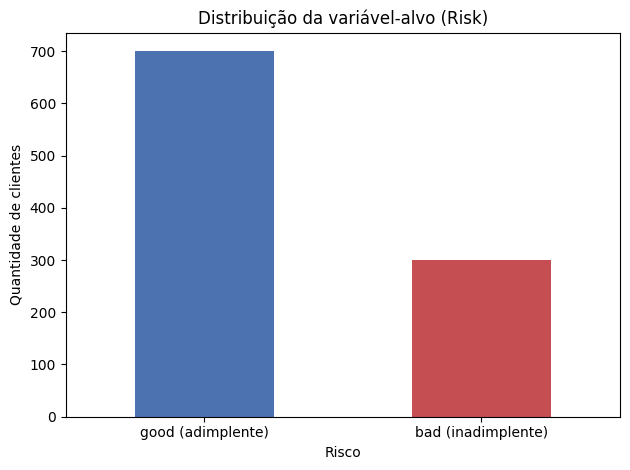

In [5]:
contagem = df['Risk'].value_counts()
proporcao = df['Risk'].value_counts(normalize=True)
print(contagem)
print()
print((proporcao * 100).round(1).astype(str) + ' %')

fig, ax = plt.subplots()
contagem.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title('Distribuição da variável-alvo (Risk)')
ax.set_xlabel('Risco')
ax.set_ylabel('Quantidade de clientes')
ax.set_xticklabels(['good (adimplente)', 'bad (inadimplente)'], rotation=0)
plt.tight_layout()
plt.savefig('fig_distribuicao_risk.png', dpi=150)
plt.show()

## 4. Distribuição das variáveis numéricas

In [6]:
df[['Age', 'Credit amount', 'Duration']].describe().round(1)

,Age,Credit amount,Duration
count,1000.0,1000.0,1000.0
mean,35.5,3271.3,20.9
std,11.4,2822.7,12.1
min,19.0,250.0,4.0
25%,27.0,1365.5,12.0
50%,33.0,2319.5,18.0
75%,42.0,3972.2,24.0
max,75.0,18424.0,72.0


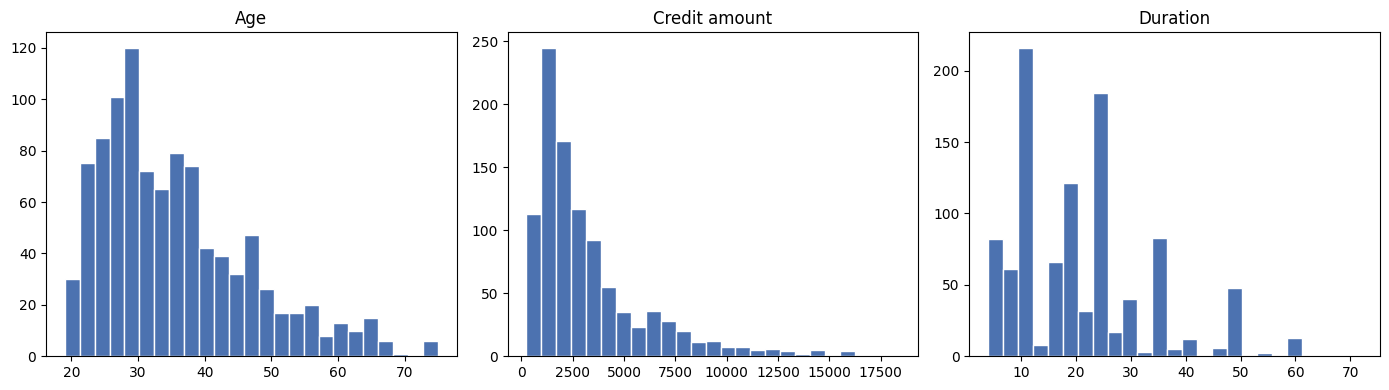

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Age', 'Credit amount', 'Duration']):
    ax.hist(df[col], bins=25, color='#4C72B0', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('fig_distribuicoes_numericas.png', dpi=150)
plt.show()

## 5. Distribuição das variáveis categóricas

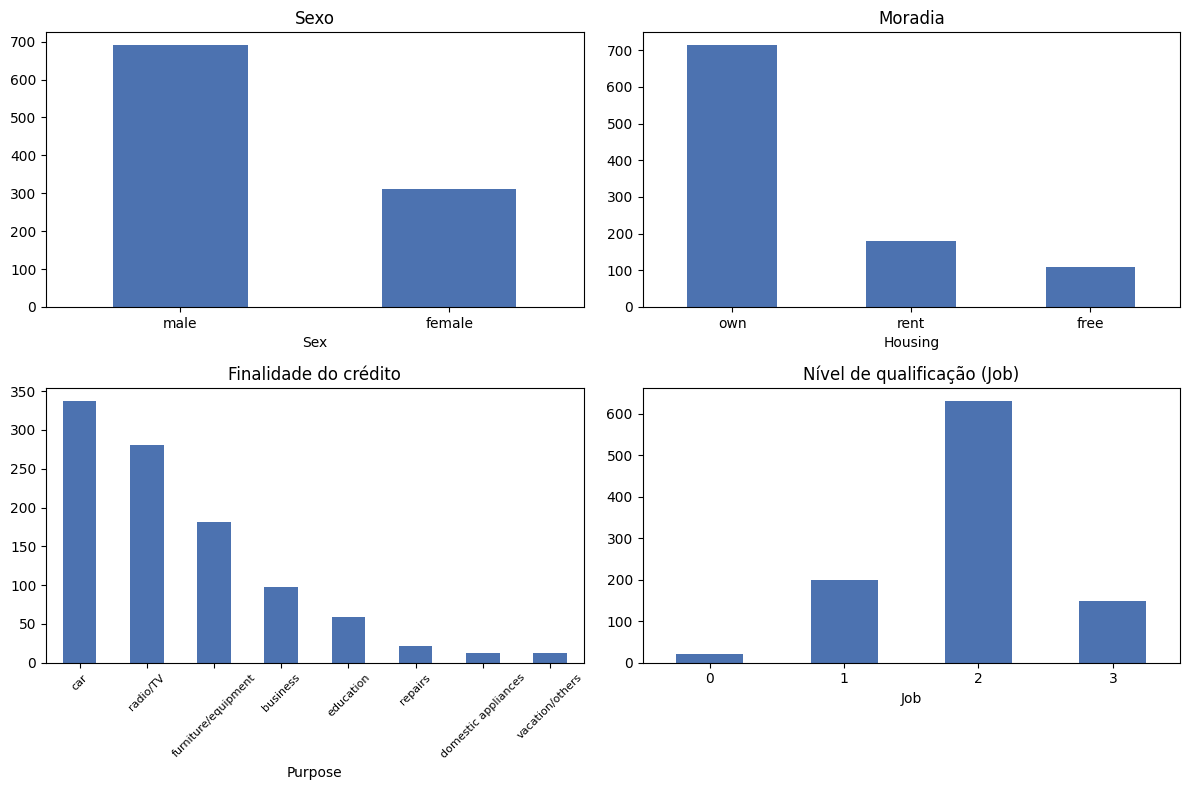

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['Sex'].value_counts().plot(kind='bar', ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Sexo')
axes[0,0].tick_params(axis='x', rotation=0)

df['Housing'].value_counts().plot(kind='bar', ax=axes[0,1], color='#4C72B0')
axes[0,1].set_title('Moradia')
axes[0,1].tick_params(axis='x', rotation=0)

df['Purpose'].value_counts().plot(kind='bar', ax=axes[1,0], color='#4C72B0')
axes[1,0].set_title('Finalidade do crédito')
axes[1,0].tick_params(axis='x', rotation=45, labelsize=8)

df['Job'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='#4C72B0')
axes[1,1].set_title('Nível de qualificação (Job)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig_distribuicoes_categoricas.png', dpi=150)
plt.show()

## 6. Relação entre as variáveis e o risco de crédito


In [9]:
taxa_por_sexo = df.groupby('Sex')['Risk'].apply(lambda s: (s == 'bad').mean())
print('Taxa de mau pagador (bad) por sexo:')
print((taxa_por_sexo * 100).round(1).astype(str) + ' %')

Taxa de mau pagador (bad) por sexo:
Sex
female    35.2 %
male      27.7 %
Name: Risk, dtype: object


In [10]:
bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

taxa_por_idade = df.groupby('AgeGroup', observed=True)['Risk'].apply(lambda s: (s == 'bad').mean())
contagem_por_idade = df['AgeGroup'].value_counts().sort_index()

print('Taxa de mau pagador (bad) por faixa etária:')
print((taxa_por_idade * 100).round(1).astype(str) + ' %')
print()
print('Quantidade de clientes por faixa etária:')
print(contagem_por_idade)

Taxa de mau pagador (bad) por faixa etária:
AgeGroup
18-25    42.1 %
26-35    29.6 %
36-45    24.3 %
46-60    26.2 %
60+      22.2 %
Name: Risk, dtype: object

Quantidade de clientes por faixa etária:
AgeGroup
18-25    190
26-35    398
36-45    226
46-60    141
60+       45
Name: count, dtype: int64


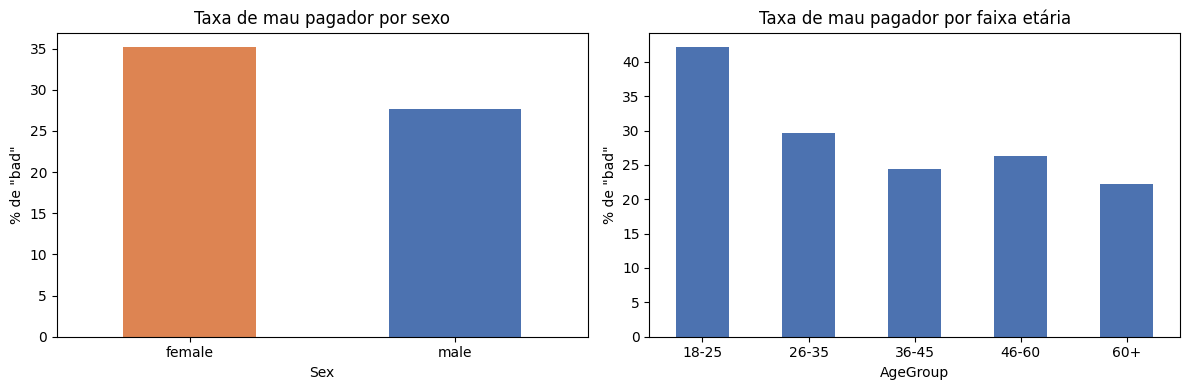

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(taxa_por_sexo * 100).plot(kind='bar', ax=axes[0], color=['#DD8452', '#4C72B0'])
axes[0].set_title('Taxa de mau pagador por sexo')
axes[0].set_ylabel('% de "bad"')
axes[0].tick_params(axis='x', rotation=0)

(taxa_por_idade * 100).plot(kind='bar', ax=axes[1], color='#4C72B0')
axes[1].set_title('Taxa de mau pagador por faixa etária')
axes[1].set_ylabel('% de "bad"')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig_risco_por_grupo.png', dpi=150)
plt.show()

In [12]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean().round(1)

,Age,Credit amount,Duration
Risk,,,
bad,34.0,3938.1,24.9
good,36.2,2985.5,19.2


In [13]:
from sklearn.model_selection import train_test_split

df_prep = df.drop(columns=['AgeGroup']).copy()

# 1. Alvo binário (1 = mau pagador / inadimplente)
df_prep['target'] = (df_prep['Risk'] == 'bad').astype(int)
df_prep = df_prep.drop(columns=['Risk'])

# 2. Ausentes como categoria "none"
df_prep['Saving accounts'] = df_prep['Saving accounts'].fillna('none')
df_prep['Checking account'] = df_prep['Checking account'].fillna('none')

# 4. Codificação ordinal (mapas definidos a partir da ordem natural das categorias)
ordem_saving = {'none': 0, 'little': 1, 'moderate': 2, 'quite rich': 3, 'rich': 4}
ordem_checking = {'none': 0, 'little': 1, 'moderate': 2, 'rich': 3}
df_prep['Saving accounts'] = df_prep['Saving accounts'].map(ordem_saving)
df_prep['Checking account'] = df_prep['Checking account'].map(ordem_checking)

# 3. One-hot para nominais
df_prep = pd.get_dummies(df_prep, columns=['Sex', 'Housing', 'Purpose'], drop_first=True)

X = df_prep.drop(columns=['target'])
y = df_prep['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('X_train:', X_train.shape, ' X_test:', X_test.shape)
print()
print('Proporção da classe positiva (bad) no treino:', y_train.mean().round(3))
print('Proporção da classe positiva (bad) no teste :', y_test.mean().round(3))
X_train.head()

X_train: (700, 16)  X_test: (300, 16)

Proporção da classe positiva (bad) no treino: 0.3
Proporção da classe positiva (bad) no teste : 0.3


,Age,Job,Saving accounts,Checking account,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
10,25,2,1,2,1295,12,False,False,True,True,False,False,False,False,False,False
82,24,1,2,0,1568,18,False,False,True,False,False,False,False,False,False,False
827,36,2,1,0,4165,18,True,True,False,False,False,False,False,False,False,False
410,20,2,1,2,1967,24,False,True,False,False,False,False,False,True,False,False
48,39,1,1,0,7228,11,True,True,False,True,False,False,False,False,False,False


## 7. Conclusões da análise exploratória

- O dataset tem 1000 registros e 9 variáveis preditoras + 1 variável-alvo, sem duplicatas
  e sem valores ausentes nas variáveis numéricas.
- As colunas Saving accounts e Checking account têm valores ausentes que, na verdade,
  parecem indicar "sem conta", e serão tratadas como categoria própria em vez de imputadas.
- A variável-alvo é desbalanceada (70% bons pagadores / 30% maus pagadores), o que exige
  tratamento específico na modelagem e o uso de métricas.
- Há diferenças descritivas na taxa de inadimplência entre sexos e faixas etárias, que
  serão acompanhadas como possíveis sinais de viés na etapa de avaliação de equidade do
  modelo.
- O plano de pré-processamento (tratamento de ausentes, codificação, padronização e
  separação treino/teste estratificada) foi definido e testado nesta etapa, e será reutilizado
  integralmente na modelagem.